<a href="https://colab.research.google.com/github/Abhi02-Sathikumar/ICT-CASE-STUDY/blob/main/Unsupervised_learning_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
adult_df = pd.read_csv("/content/adult_dataset.csv")
adult_df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [4]:
adult_df.isna().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [5]:
adult_df.duplicated().sum()

np.int64(16)

In [6]:
adult_df = adult_df.drop_duplicates()

[]

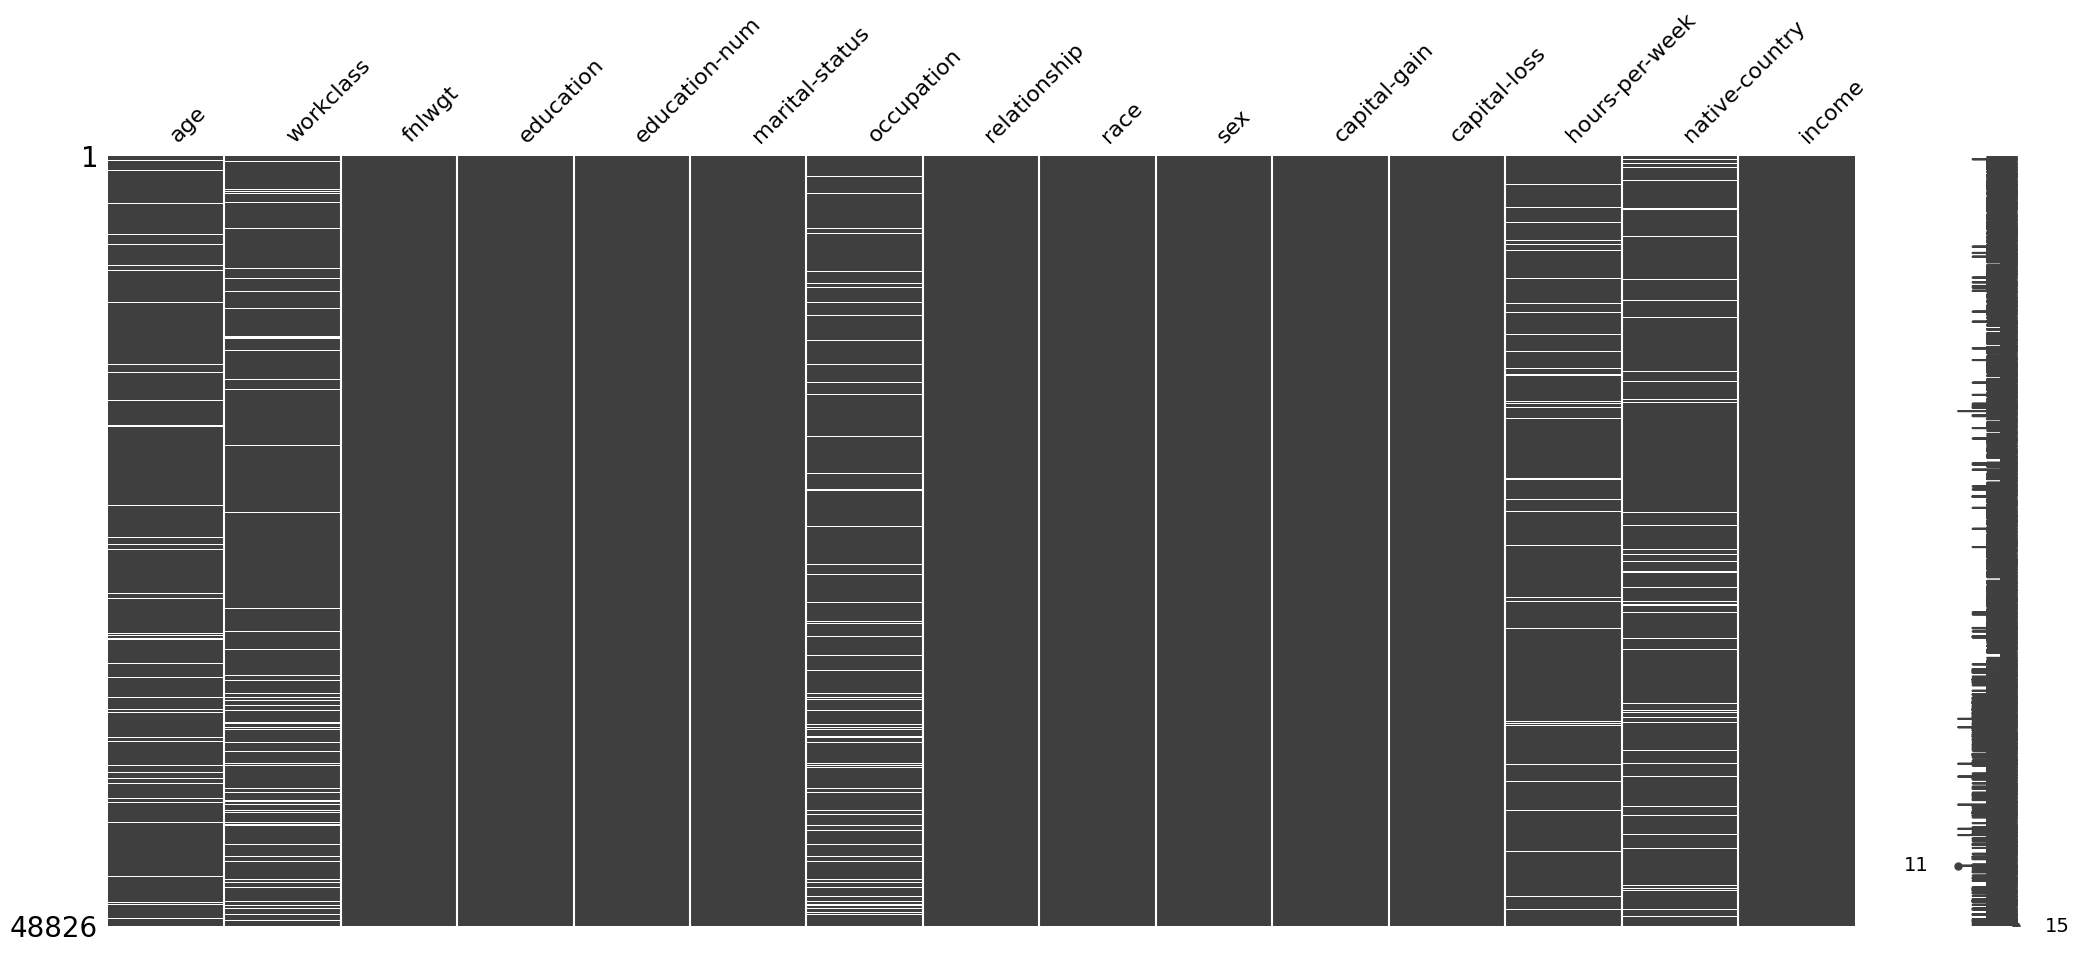

In [7]:
import missingno as msn
msn.matrix(adult_df)
plt.plot()

In [8]:
adult_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48826 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46384 non-null  float64
 1   workclass       45464 non-null  object 
 2   fnlwgt          48826 non-null  int64  
 3   education       48826 non-null  object 
 4   education-num   48826 non-null  int64  
 5   marital-status  48826 non-null  object 
 6   occupation      45469 non-null  object 
 7   relationship    48826 non-null  object 
 8   race            48826 non-null  object 
 9   sex             48826 non-null  object 
 10  capital-gain    48826 non-null  int64  
 11  capital-loss    48826 non-null  int64  
 12  hours-per-week  46384 non-null  float64
 13  native-country  46121 non-null  object 
 14  income          48826 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 6.0+ MB


In [9]:
missing = (adult_df =='?').sum()
print(missing)

age                  0
workclass         1763
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1758
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     555
income               0
dtype: int64


In [10]:
adult_df = adult_df.replace('?',np.nan)

In [11]:
adult_df = adult_df.fillna(adult_df.mean(numeric_only=True))

In [12]:
adult_df.isna().sum()

,0
age,0
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [13]:
for col in adult_df.select_dtypes(include=['object']).columns:
    adult_df[col] = adult_df[col].fillna(adult_df[col].mode()[0])

<Axes: >

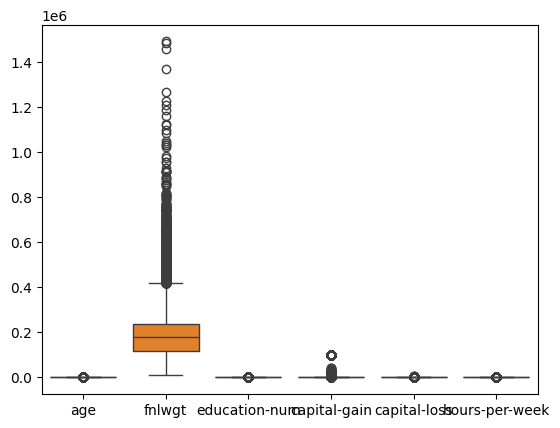

In [14]:
sns.boxplot(adult_df)

In [15]:
columns = adult_df.columns

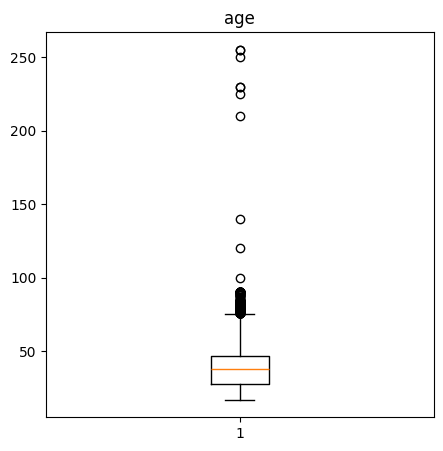

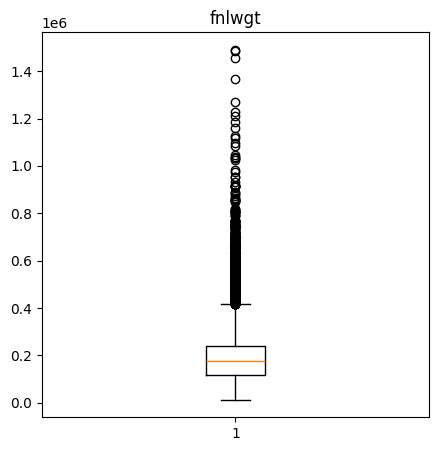

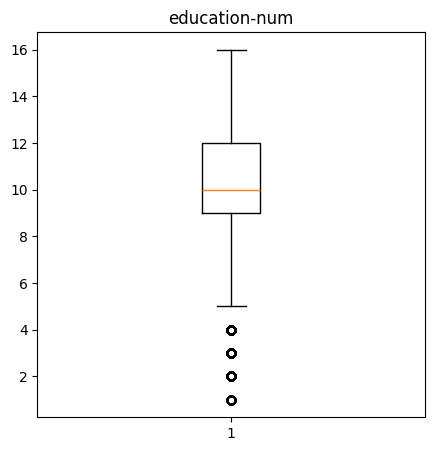

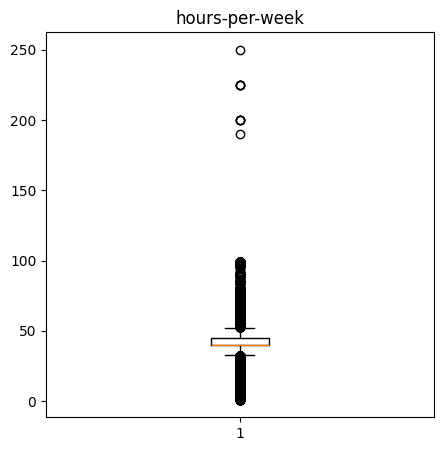

In [16]:
numerical_cols = ['age', 'fnlwgt', 'education-num', 'hours-per-week']
for i in numerical_cols:
  plt.figure(figsize=(5,5))
  plt.boxplot(adult_df[i])
  plt.title(i)

In [17]:
for col in numerical_cols:
  Q1=adult_df[col].quantile(0.25)
  Q3=adult_df[col].quantile(0.75)
  IQR=Q3-Q1
  lower_bound=Q1-1.5*IQR
  upper_bound=Q3+1.5*IQR
  adult_df[col] = adult_df[col].clip(lower_bound,upper_bound)

<Axes: >

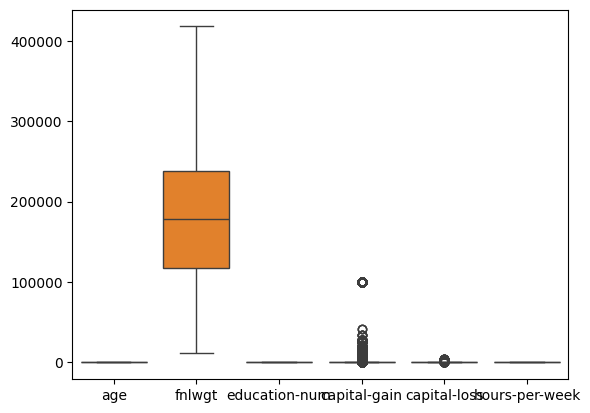

In [18]:
sns.boxplot(adult_df)

In [19]:
adult_df.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,32.5,United-States,<=50K
2,38.0,Private,215646,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K
5,37.0,Private,284582,Masters,14.0,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40.0,United-States,<=50K
6,49.0,Private,160187,9th,5.0,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,32.5,Jamaica,<=50K
7,52.0,Self-emp-not-inc,209642,HS-grad,9.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45.0,United-States,>50K
8,31.0,Private,45781,Masters,14.0,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50.0,United-States,>50K
9,42.0,Private,159449,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40.0,United-States,>50K


In [20]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

label_encoder = LabelEncoder()

columns_to_encode = [
    'workclass',
    'education',
    'marital-status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native-country',
    'income'
]

for col in columns_to_encode:
    adult_df[col] = label_encoder.fit_transform(adult_df[col])
    print(f"Column '{col}' encoded successfully.")

display(adult_df.head())
print("\nData types after encoding:")
display(adult_df[columns_to_encode].dtypes)

Column 'workclass' encoded successfully.
Column 'education' encoded successfully.
Column 'marital-status' encoded successfully.
Column 'occupation' encoded successfully.
Column 'relationship' encoded successfully.
Column 'race' encoded successfully.
Column 'sex' encoded successfully.
Column 'native-country' encoded successfully.
Column 'income' encoded successfully.


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,6,77516,9,13.0,4,0,1,4,1,2174,0,40.0,38,0
1,50.0,5,83311,9,13.0,2,3,0,4,1,0,0,32.5,38,0
2,38.0,3,215646,11,9.0,0,5,1,4,1,0,0,40.0,38,0
3,53.0,3,234721,1,7.0,2,5,0,2,1,0,0,40.0,38,0
4,28.0,3,338409,9,13.0,2,9,5,2,0,0,0,40.0,4,0



Data types after encoding:


,0
workclass,int64
education,int64
marital-status,int64
occupation,int64
relationship,int64
race,int64
sex,int64
native-country,int64
income,int64


In [21]:
numerical_cols = adult_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
print("Numerical columns found:", numerical_cols)

columns_to_exclude = []

features_to_scale = [col for col in numerical_cols if col not in columns_to_exclude]
print(f"\nFeatures that will be scaled:\n{features_to_scale}\n")

scaler = StandardScaler()

adult_df = adult_df.copy()
adult_df[features_to_scale] = scaler.fit_transform(adult_df[features_to_scale])

adult_df[features_to_scale].head()

Numerical columns found: ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Features that will be scaled:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']



,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,0.028795,2.689325,-1.146152,-0.332588,1.171344,0.916280,-1.607341,-0.276694,0.392425,0.704165,0.146861,-0.217164,-0.191218,0.253152,-0.834741
1,0.858028,1.763610,-1.085355,-0.332588,1.171344,-0.410262,-0.841717,-0.900793,0.392425,0.704165,-0.144828,-0.217164,-1.434968,0.253152,-0.834741
2,-0.046590,-0.087820,0.303009,0.183622,-0.456772,-1.736803,-0.331301,-0.276694,0.392425,0.704165,-0.144828,-0.217164,-0.191218,0.253152,-0.834741
3,1.084182,-0.087820,0.503130,-2.397429,-1.270830,-0.410262,-0.331301,-0.900793,-1.971614,0.704165,-0.144828,-0.217164,-0.191218,0.253152,-0.834741
4,-0.800438,-0.087820,1.590950,-0.332588,1.171344,-0.410262,0.689531,2.219701,-1.971614,-1.420121,-0.144828,-0.217164,-0.191218,-5.513621,-0.834741


In [22]:
adult_df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,0.028795,2.689325,-1.146152,-0.332588,1.171344,0.916280,-1.607341,-0.276694,0.392425,0.704165,0.146861,-0.217164,-0.191218,0.253152,-0.834741
1,0.858028,1.763610,-1.085355,-0.332588,1.171344,-0.410262,-0.841717,-0.900793,0.392425,0.704165,-0.144828,-0.217164,-1.434968,0.253152,-0.834741
2,-0.046590,-0.087820,0.303009,0.183622,-0.456772,-1.736803,-0.331301,-0.276694,0.392425,0.704165,-0.144828,-0.217164,-0.191218,0.253152,-0.834741
3,1.084182,-0.087820,0.503130,-2.397429,-1.270830,-0.410262,-0.331301,-0.900793,-1.971614,0.704165,-0.144828,-0.217164,-0.191218,0.253152,-0.834741
4,-0.800438,-0.087820,1.590950,-0.332588,1.171344,-0.410262,0.689531,2.219701,-1.971614,-1.420121,-0.144828,-0.217164,-0.191218,-5.513621,-0.834741


Text(0, 0.5, 'Count')

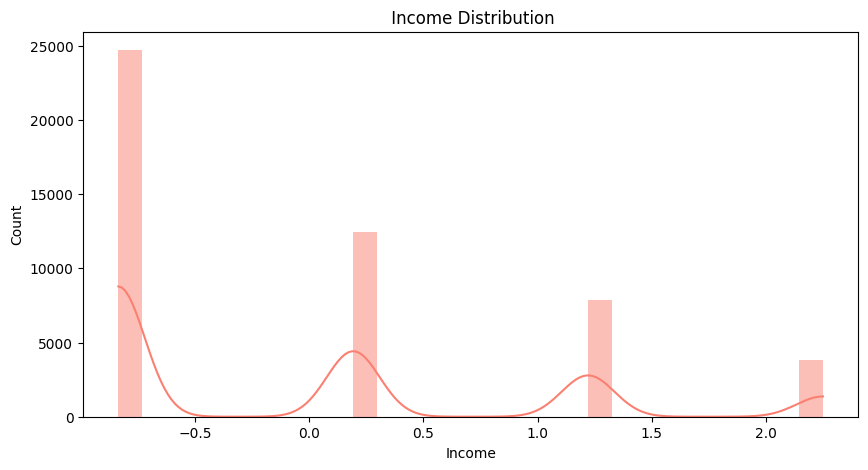

In [23]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.figure(figsize=(10, 5))

sns.histplot(
    adult_df['income'],
    kde=True,
    bins=30,
    color='salmon',
    edgecolor='none',
)
plt.title(' Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')

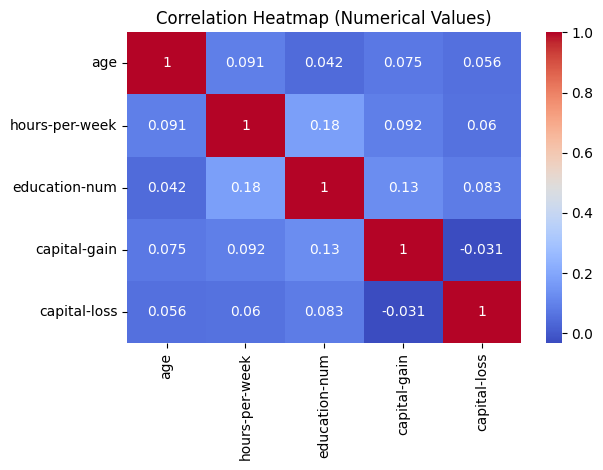

In [24]:
num_cols = ['age', 'hours-per-week', 'education-num', 'capital-gain', 'capital-loss']

corr = adult_df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap (Numerical Values)')
plt.tight_layout()
plt.show()

In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


numerical_features = ['age', 'hours-per-week', 'capital-gain', 'capital-loss']
X_num = adult_df[numerical_features].dropna()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)


pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.29675522, 0.25749243])

In [32]:
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

df_pca['income'] = adult_df.loc[X_num.index, 'income'].values

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_pca,
    x='PC1',
    y='PC2',
    hue='income',
    alpha=0.6,
    palette='viridis'
)

plt.title('PCA: Principal Component 1 vs Principal Component 2', fontsize=14)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Income')
plt.show()

NameError: name 'pca_result' is not defined

<Figure size 800x600 with 0 Axes>

In [27]:
from sklearn.cluster import KMeans

x=adult_df.values
wcss_list=[]
for i in range (1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(x)
  wcss_list.append(kmeans.inertia_)


wcss_list

[732390.0000000037,
 649359.9346947584,
 606558.7226032066,
 575510.6284835724,
 570102.1556076217,
 539272.054461459,
 502448.6452099659,
 473563.3346419842,
 443992.05190815654,
 403288.1452740912]

Text(0, 0.5, 'wcss')

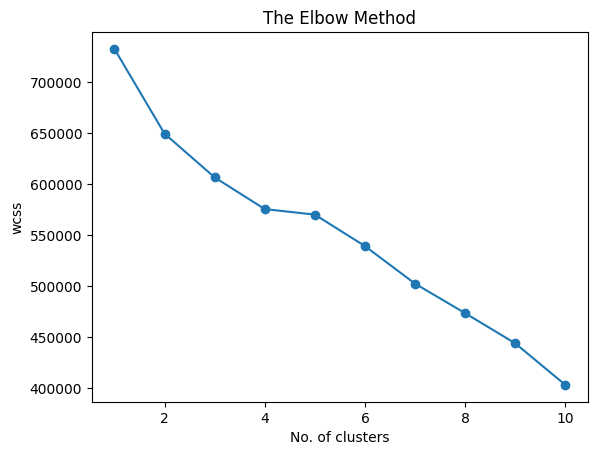

In [28]:
plt.plot(range(1,11),wcss_list,marker='o')
plt.title('The Elbow Method')
plt.xlabel('No. of clusters')
plt.ylabel('wcss')

In [29]:
kmeans_model = KMeans(n_clusters = 5, init='k-means++',random_state=42, n_init=10)
y_predict = kmeans_model.fit_predict(x)
y_predict

array([3, 3, 3, ..., 0, 3, 0], dtype=int32)

In [30]:
adult_df['kmeans_cluster'] = y_predict
adult_df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,kmeans_cluster
0,0.028795,2.689325,-1.146152,-0.332588,1.171344,0.916280,-1.607341,-0.276694,0.392425,0.704165,0.146861,-0.217164,-0.191218,0.253152,-0.834741,3
1,0.858028,1.763610,-1.085355,-0.332588,1.171344,-0.410262,-0.841717,-0.900793,0.392425,0.704165,-0.144828,-0.217164,-1.434968,0.253152,-0.834741,3
2,-0.046590,-0.087820,0.303009,0.183622,-0.456772,-1.736803,-0.331301,-0.276694,0.392425,0.704165,-0.144828,-0.217164,-0.191218,0.253152,-0.834741,3
3,1.084182,-0.087820,0.503130,-2.397429,-1.270830,-0.410262,-0.331301,-0.900793,-1.971614,0.704165,-0.144828,-0.217164,-0.191218,0.253152,-0.834741,4
4,-0.800438,-0.087820,1.590950,-0.332588,1.171344,-0.410262,0.689531,2.219701,-1.971614,-1.420121,-0.144828,-0.217164,-0.191218,-5.513621,-0.834741,1


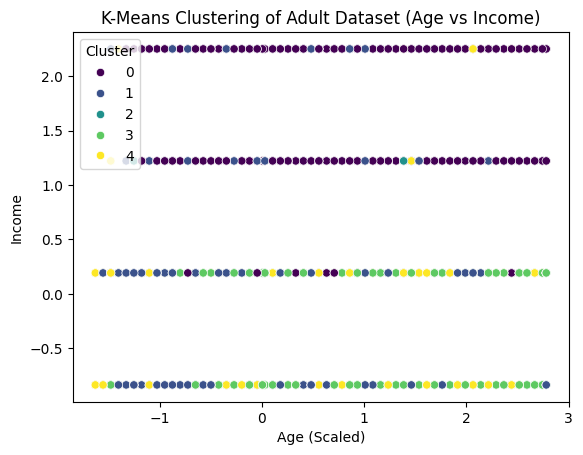

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='age', y='income', data=adult_df, hue='kmeans_cluster', palette='viridis')
plt.xlabel('Age (Scaled)')
plt.ylabel('Income')
plt.title('K-Means Clustering of Adult Dataset (Age vs Income)')
plt.legend(title='Cluster')
plt.show()

In [35]:
from sklearn.metrics import silhouette_score
silhouette_average=silhouette_score(x,y_predict)
print('Silhouette_score: ', silhouette_average)

Silhouette_score:  0.10314576499439937


In [36]:
x_sample = x[:1000]

In [39]:
adult_sample = adult_df.iloc[:1000].copy()

In [41]:
from sklearn.cluster import AgglomerativeClustering

agg_clustering = AgglomerativeClustering(
    n_clusters=5
)

agg_predict = agg_clustering.fit_predict(x_sample)
adult_sample['agglomerative_cluster'] = agg_predict

adult_sample.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,kmeans_cluster,agglomerative_cluster
0,0.028795,2.689325,-1.146152,-0.332588,1.171344,0.916280,-1.607341,-0.276694,0.392425,0.704165,0.146861,-0.217164,-0.191218,0.253152,-0.834741,3,1
1,0.858028,1.763610,-1.085355,-0.332588,1.171344,-0.410262,-0.841717,-0.900793,0.392425,0.704165,-0.144828,-0.217164,-1.434968,0.253152,-0.834741,3,1
2,-0.046590,-0.087820,0.303009,0.183622,-0.456772,-1.736803,-0.331301,-0.276694,0.392425,0.704165,-0.144828,-0.217164,-0.191218,0.253152,-0.834741,3,0
3,1.084182,-0.087820,0.503130,-2.397429,-1.270830,-0.410262,-0.331301,-0.900793,-1.971614,0.704165,-0.144828,-0.217164,-0.191218,0.253152,-0.834741,4,3
4,-0.800438,-0.087820,1.590950,-0.332588,1.171344,-0.410262,0.689531,2.219701,-1.971614,-1.420121,-0.144828,-0.217164,-0.191218,-5.513621,-0.834741,1,4


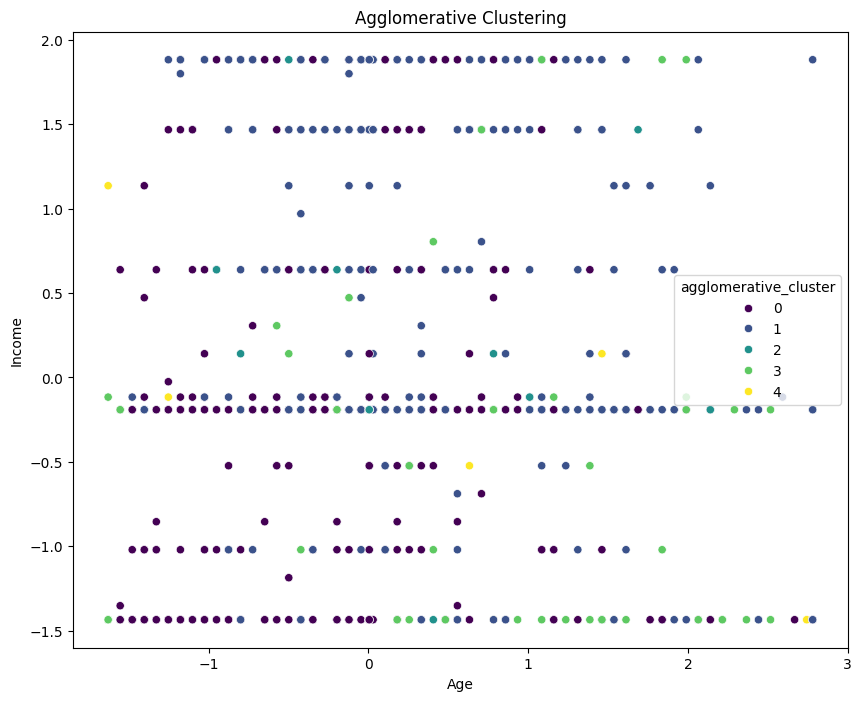

In [43]:
plt.figure(figsize=(10, 8))

sns.scatterplot(x='age',y='hours-per-week', data=adult_sample,hue='agglomerative_cluster',palette='viridis')

plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Agglomerative Clustering')

plt.show()

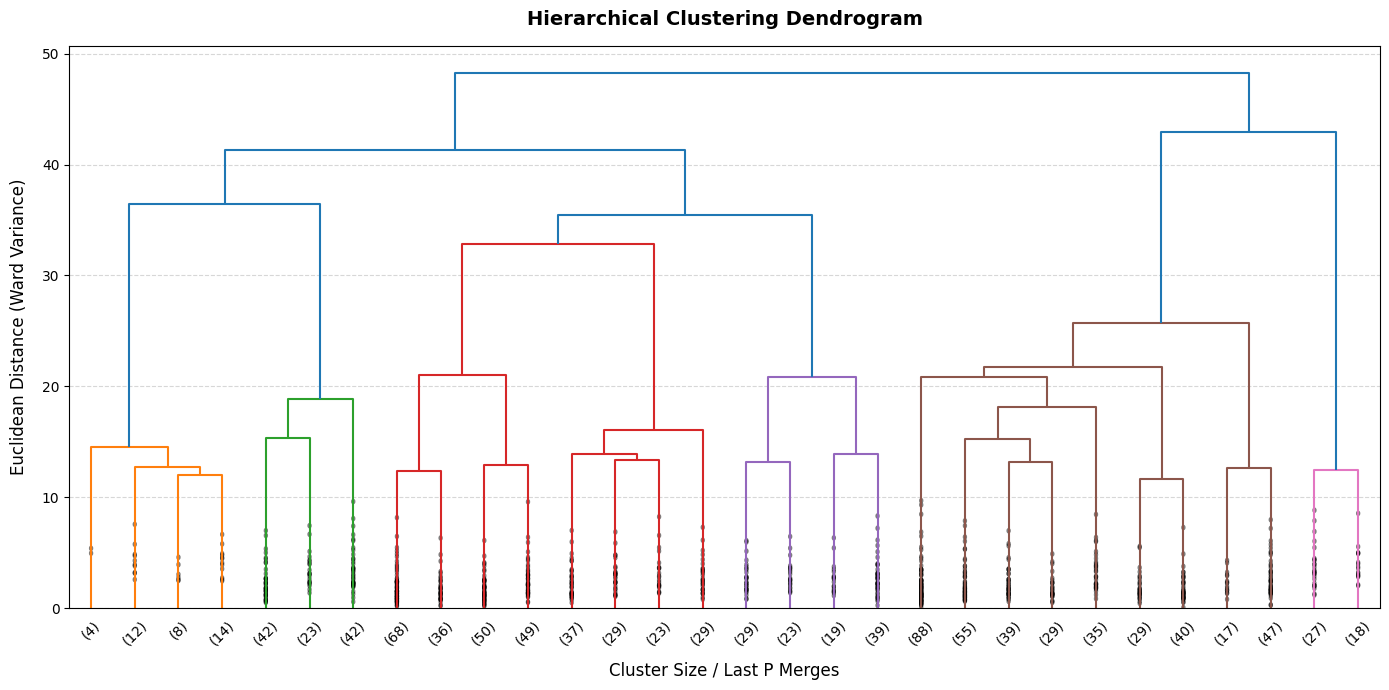

In [47]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(x_sample, method='ward', optimal_ordering=True)

plt.figure(figsize=(14, 7), dpi=100)

denddrs = dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    leaf_rotation=45.0,
    leaf_font_size=10.0,
    show_contracted=True,
    color_threshold=0.7
    * max(Z[:, 2]),
)

plt.title(
    'Hierarchical Clustering Dendrogram',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Cluster Size / Last P Merges', fontsize=12, labelpad=10)
plt.ylabel('Euclidean Distance (Ward Variance)', fontsize=12, labelpad=10)


plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [56]:
from scipy.cluster.hierarchy import fcluster, linkage

max_clust = 3
cluster_labels = fcluster(Z, t=max_clust, criterion='maxclust')
adult_sample['Cluster'] = cluster_labels

cluster_profiles = adult_sample.groupby('Cluster').agg(
    {
        'age': 'mean',
        'hours-per-week': 'mean',
        'education-num': 'mean',
        'capital-gain': 'mean',
        'capital-loss': 'mean',
    }
)

print('--- Numerical Feature Means per Cluster ---')
display(cluster_profiles)

for cluster_id, group in adult_sample.groupby('Cluster'):
  print(f'\n--- Cluster {cluster_id} Profile ---')
  print(f"Size: {len(group)} rows")
  print('Top Education Levels:\n')
  display(group['education'].value_counts().head(3))
  print('Top Occupations:\n')
  display(group['occupation'].value_counts().head(3))

  if 'income' in adult_sample.columns:
    print('Income Distribution:\n')
    display(group['income'].value_counts(normalize=True))

'--- Numerical Feature Means per Cluster ---'

,age,hours-per-week,education-num,capital-gain,capital-loss
Cluster,,,,,
1,-0.243780,-0.330182,-0.215805,-0.092759,-0.184433
2,0.246196,0.390387,0.323457,-0.015614,-0.212890
3,0.157557,0.202916,0.131159,-0.144828,4.453069



--- Cluster 1 Profile ---
Size: 576 rows
Top Education Levels:



,count
education,
0.183622,174
1.216043,130
-0.332588,74


Top Occupations:



...

,count
education,
1.216043,10
0.183622,9
-0.332588,5


Top Occupations:



,count
occupation,
0.689531,12
-0.841717,7
-1.096925,6


Income Distribution:



,proportion
income,
-0.834741,0.6
1.221101,0.4
